In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from textProcessing import textProcessing
import nltk
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
import string
from collections import Counter
import pyLDAvis
import pyLDAvis.lda_model
from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Morgan\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
df = pd.read_csv("housing_crisis_nlp_data.csv")
display(df)

,Video_ID,User,Text,Date,Likes,Is_Reply,Video_Published_Date
0,vWlh41jJ2Ww,@davidwalden2887,The housing shortage in Australia will be imme...,2026-05-16T13:44:12Z,0,False,2024-09-03 04:49:15+00:00
1,vWlh41jJ2Ww,@ColdPatterns,My last neighbour was a single 65 year old guy...,2026-02-22T17:48:56Z,0,False,2024-09-03 04:49:15+00:00
2,vWlh41jJ2Ww,@StephP2025,We should all go back to where we came from. S...,2026-01-30T14:50:16Z,0,False,2024-09-03 04:49:15+00:00
3,vWlh41jJ2Ww,@bull13__x,Bitcoin fixes this,2026-01-15T21:23:02Z,0,False,2024-09-03 04:49:15+00:00
4,vWlh41jJ2Ww,@joebullwinkle5099,The systemic failure in housing is that the is...,2026-01-01T19:46:16Z,0,False,2024-09-03 04:49:15+00:00
...,...,...,...,...,...,...,...
20080,RJDVeLa7uXg,@U.s.e.r.3493,Immigrants arent the majority buying houses......,2026-03-26T07:21:58Z,0,True,2026-03-26 06:00:16+00:00
20081,RJDVeLa7uXg,@offcut7167,Australia has a lot of resources and big oppor...,2026-03-26T08:31:58Z,0,True,2026-03-26 06:00:16+00:00
20082,RJDVeLa7uXg,@U.s.e.r.3493,​@offcut7167ah so you're saying that even if w...,2026-03-26T09:15:35Z,1,True,2026-03-26 06:00:16+00:00
20083,RJDVeLa7uXg,@offcut7167,​​@U.s.e.r.3493Yeah two tiered society. The ol...,2026-03-26T09:27:48Z,2,True,2026-03-26 06:00:16+00:00


In [3]:
tweetTokenizer = TweetTokenizer()
lPunct = list(string.punctuation)
lStopwords = stopwords.words('english') + lPunct + ['rt', 'via', '...', '…', '"', "'", '`', '’', '”', '—', '°', '“', '..', ':', '::']
processor = textProcessing(tweetTokenizer, lStopwords)
df['Text'] = df['Text'].fillna('').astype(str)
df['processedTokens'] = df['Text'].apply(processor.processText)
df['halfProcessedTokens'] = df['Text'].apply(processor.halfPreprocessText)

preUniqueWords = processor.returnUniqueWords(df, 'halfProcessedTokens')
postUniqueWords = processor.returnUniqueWords(df, 'processedTokens')
print(preUniqueWords.most_common(20))
print(postUniqueWords.most_common(20))

[('.', 36111), ('the', 28762), (',', 22370), ('to', 20683), ('and', 16963), ('a', 15313), ('of', 12377), ('is', 11816), ('in', 11544), ('for', 7826), ('are', 6808), ('that', 6804), ('it', 6288), ('I', 6153), ('you', 5911), ('have', 4976), ('they', 4720), ('on', 4718), ('’', 4603), ('be', 4467)]
[('people', 4372), ('housing', 4040), ('government', 2834), ('house', 2554), ('australia', 2413), ('would', 2284), ('like', 2093), ('get', 1981), ('prices', 1976), ('property', 1931), ('immigration', 1795), ('one', 1738), ('home', 1701), ('money', 1678), ('houses', 1612), ('years', 1565), ('need', 1518), ('tax', 1495), ('going', 1395), ('buy', 1369)]


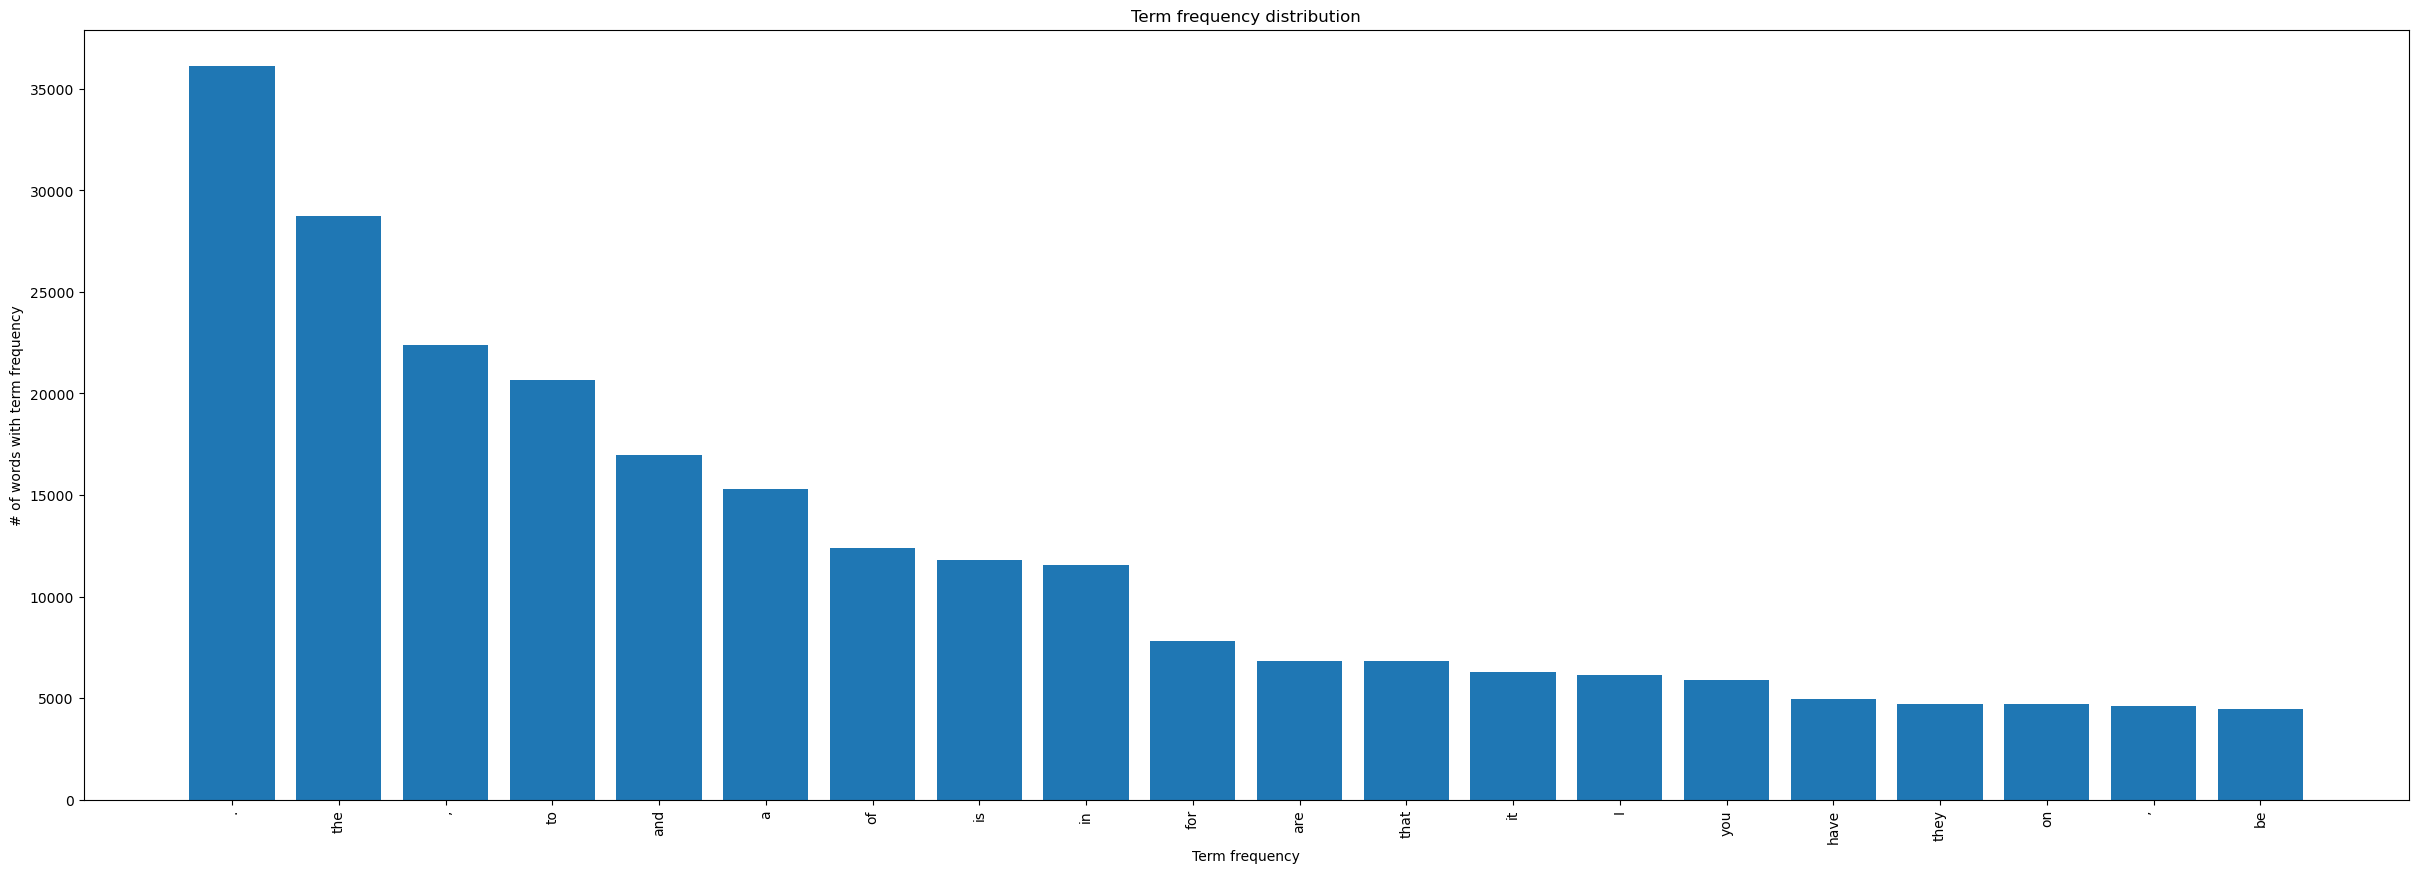

In [4]:

processor.outputGraphWordFreq(preUniqueWords, 20)

Word frequency before processing

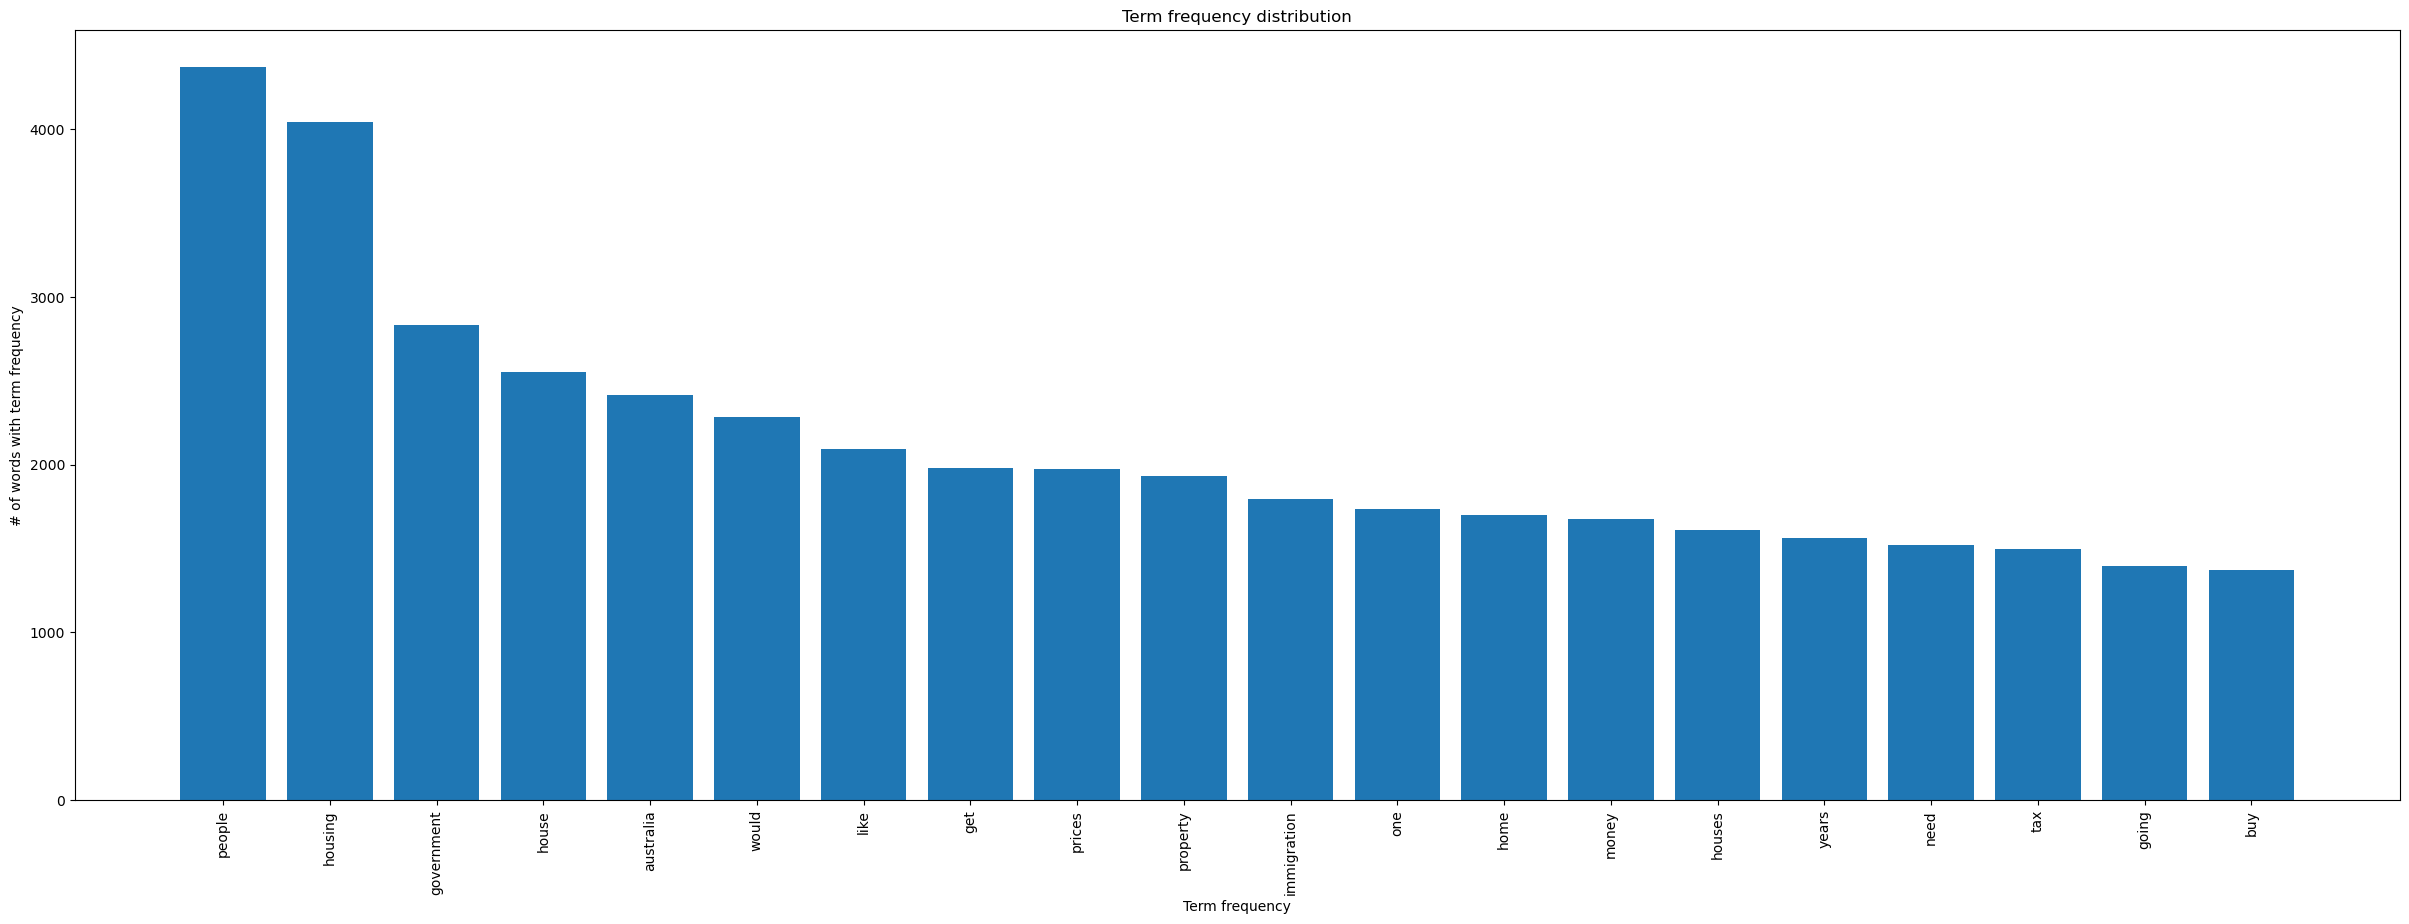

In [5]:
processor.outputGraphWordFreq(postUniqueWords, 20)

Word frequency after processing

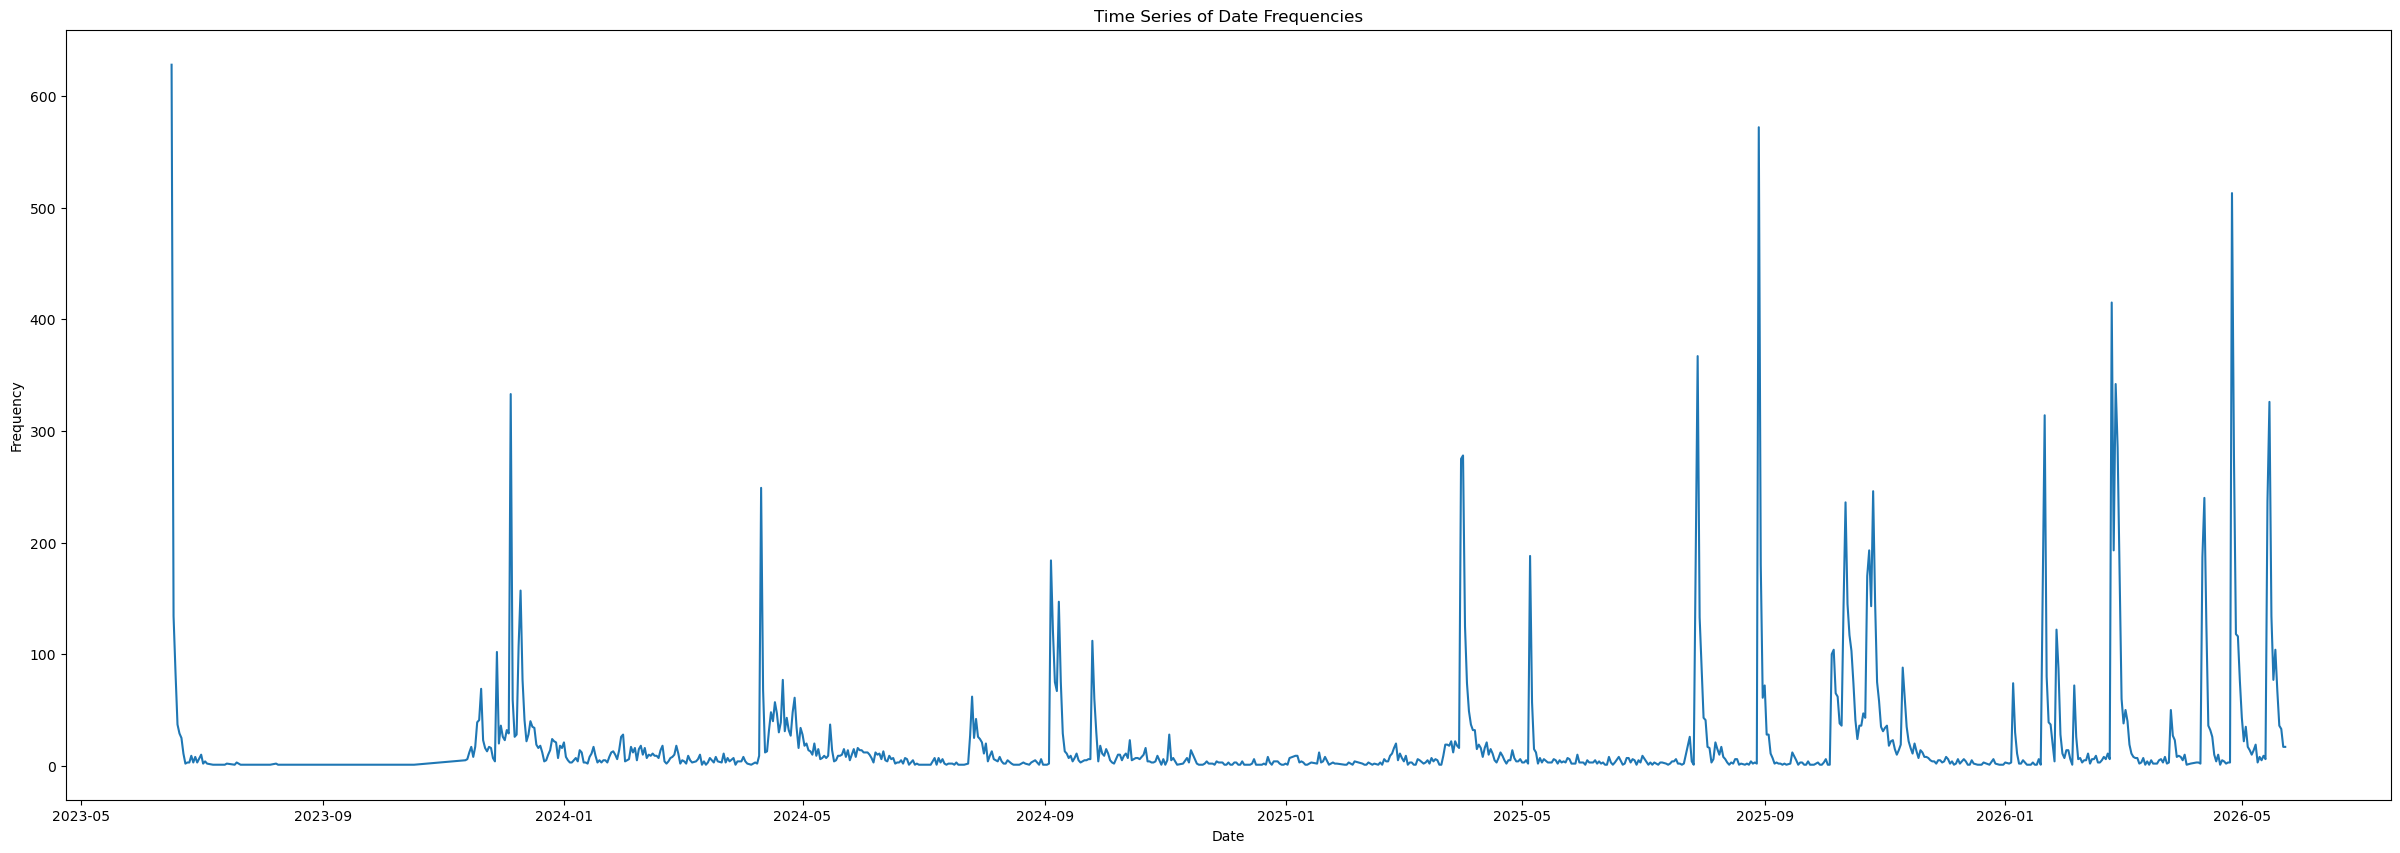

In [6]:
processor.outputGraphTimeSeries(df)

Time series graph of comments

In [7]:
dfAnalysed = pd.read_csv("housing_crisis_nlp_analysed.csv")
display(dfAnalysed)



,Video_ID,User,Text,Date,Likes,Is_Reply,Video_Published_Date,Topic_Cluster,Predominant_Emotion
0,vWlh41jJ2Ww,@davidwalden2887,The housing shortage in Australia will be imme...,2026-05-16T13:44:12Z,0,False,2024-09-03 04:49:15+00:00,-1,neutral
1,vWlh41jJ2Ww,@ColdPatterns,My last neighbour was a single 65 year old guy...,2026-02-22T17:48:56Z,0,False,2024-09-03 04:49:15+00:00,-1,neutral
2,vWlh41jJ2Ww,@StephP2025,We should all go back to where we came from. S...,2026-01-30T14:50:16Z,0,False,2024-09-03 04:49:15+00:00,-1,neutral
3,vWlh41jJ2Ww,@bull13__x,Bitcoin fixes this,2026-01-15T21:23:02Z,0,False,2024-09-03 04:49:15+00:00,118,neutral
4,vWlh41jJ2Ww,@joebullwinkle5099,The systemic failure in housing is that the is...,2026-01-01T19:46:16Z,0,False,2024-09-03 04:49:15+00:00,-1,neutral
...,...,...,...,...,...,...,...,...,...
20079,RJDVeLa7uXg,@U.s.e.r.3493,Immigrants arent the majority buying houses......,2026-03-26T07:21:58Z,0,True,2026-03-26 06:00:16+00:00,2,neutral
20080,RJDVeLa7uXg,@offcut7167,Australia has a lot of resources and big oppor...,2026-03-26T08:31:58Z,0,True,2026-03-26 06:00:16+00:00,-1,neutral
20081,RJDVeLa7uXg,@U.s.e.r.3493,​@offcut7167ah so you're saying that even if w...,2026-03-26T09:15:35Z,1,True,2026-03-26 06:00:16+00:00,152,neutral
20082,RJDVeLa7uXg,@offcut7167,​​@U.s.e.r.3493Yeah two tiered society. The ol...,2026-03-26T09:27:48Z,2,True,2026-03-26 06:00:16+00:00,-1,neutral


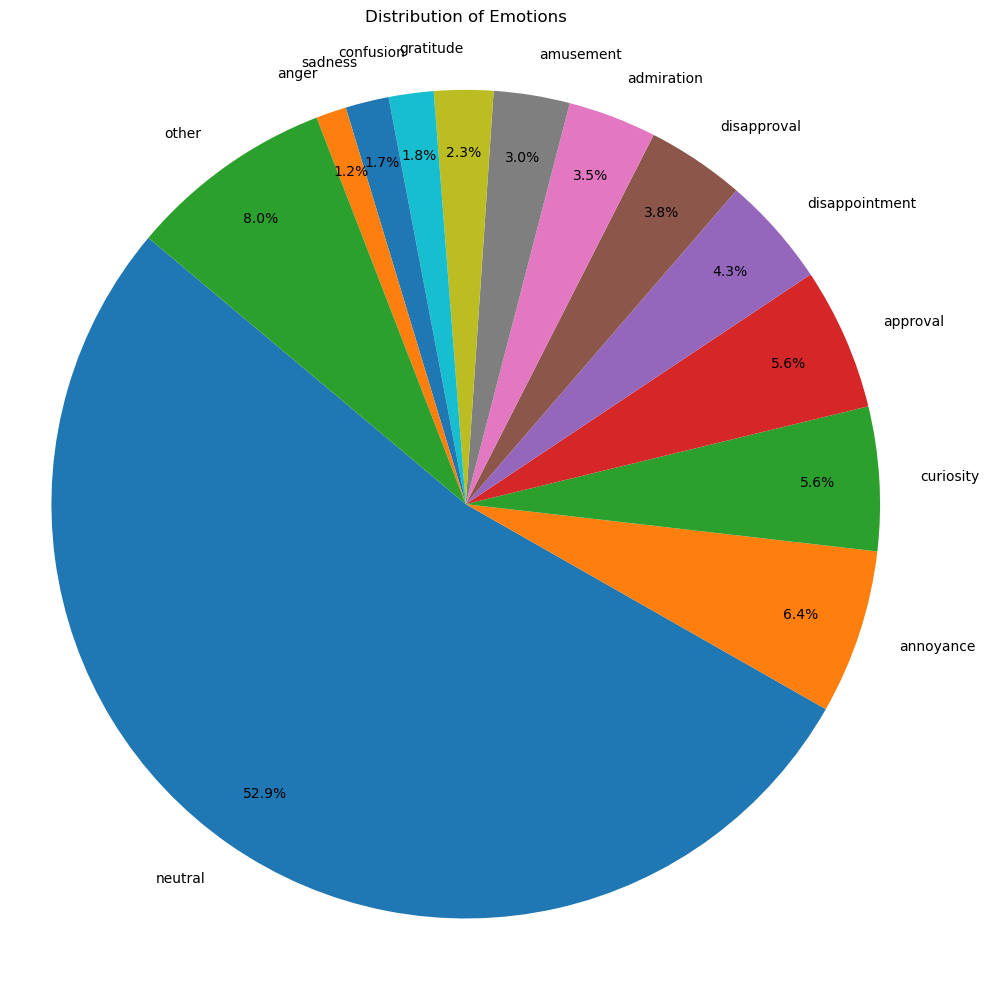

In [8]:
processor.outputGraphEmotionPieChart(dfAnalysed, 12)

Emotions/Sentiment analysis of comments

In [9]:
communities = pd.read_csv("video_community_analysis.csv")
communityArr = []

for _, row in communities.iterrows():
    currIds = row['Videos']
    communityArr.append([row['Community_ID'], currIds.split('; ')])
    

In [10]:
def getCommunity(Video_ID, communityArr):
    for commId, vids in communityArr:
        if Video_ID in vids:
            return commId
    return -1
    
dfAnalysed['Community_ID'] = dfAnalysed['Video_ID'].apply(lambda vid: getCommunity(vid, communityArr))
comm0 = dfAnalysed[dfAnalysed['Community_ID'] == 0]
comm1 = dfAnalysed[dfAnalysed['Community_ID'] == 1]
comm2 = dfAnalysed[dfAnalysed['Community_ID'] == 2]

Community zero sentiment analysis

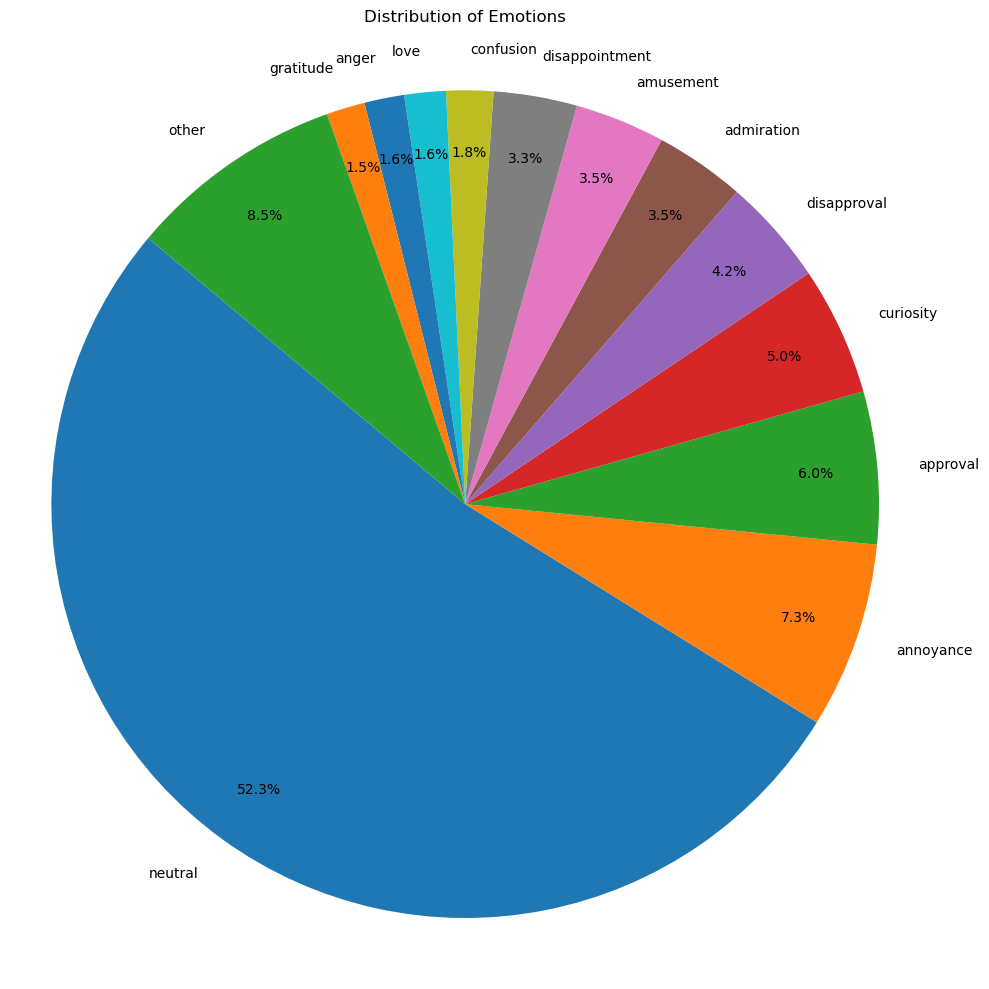

In [11]:
processor.outputGraphEmotionPieChart(comm0, 12)

Community one sentiment analysis

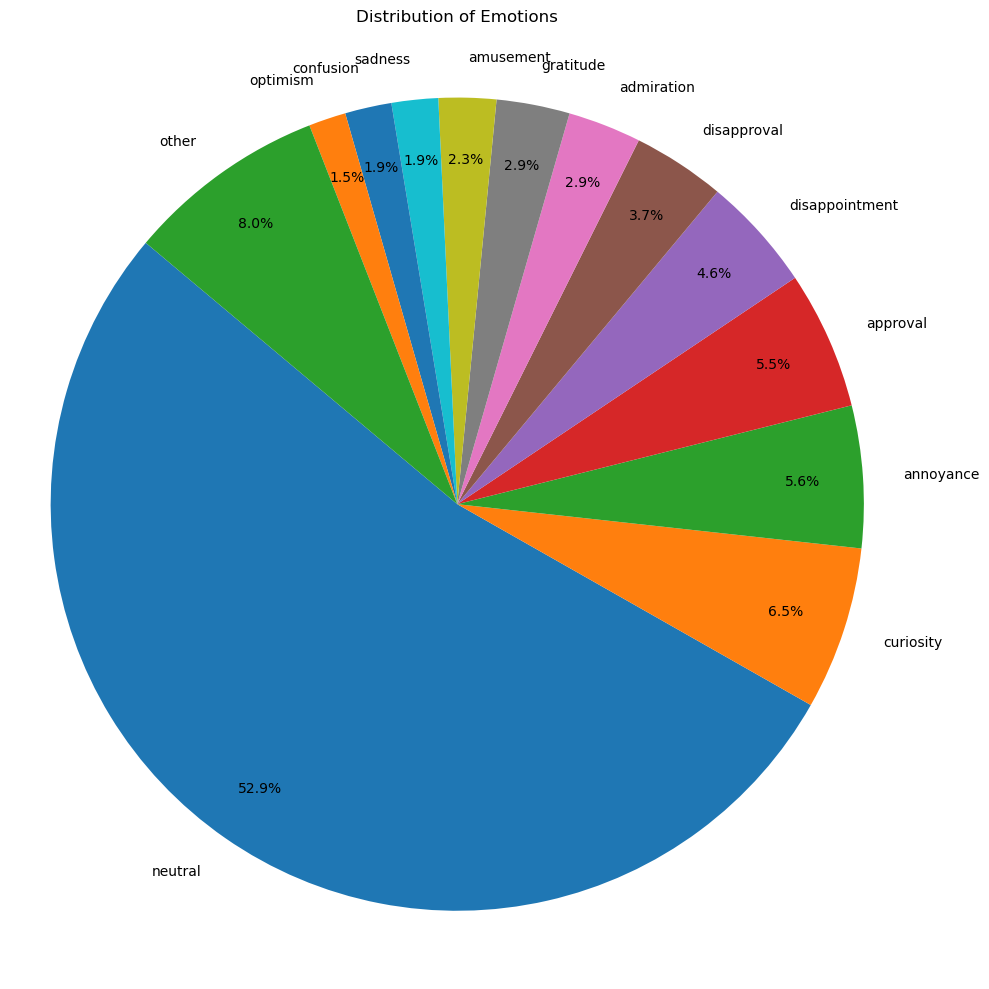

In [12]:
processor.outputGraphEmotionPieChart(comm1, 12)

community two sentiment analysis

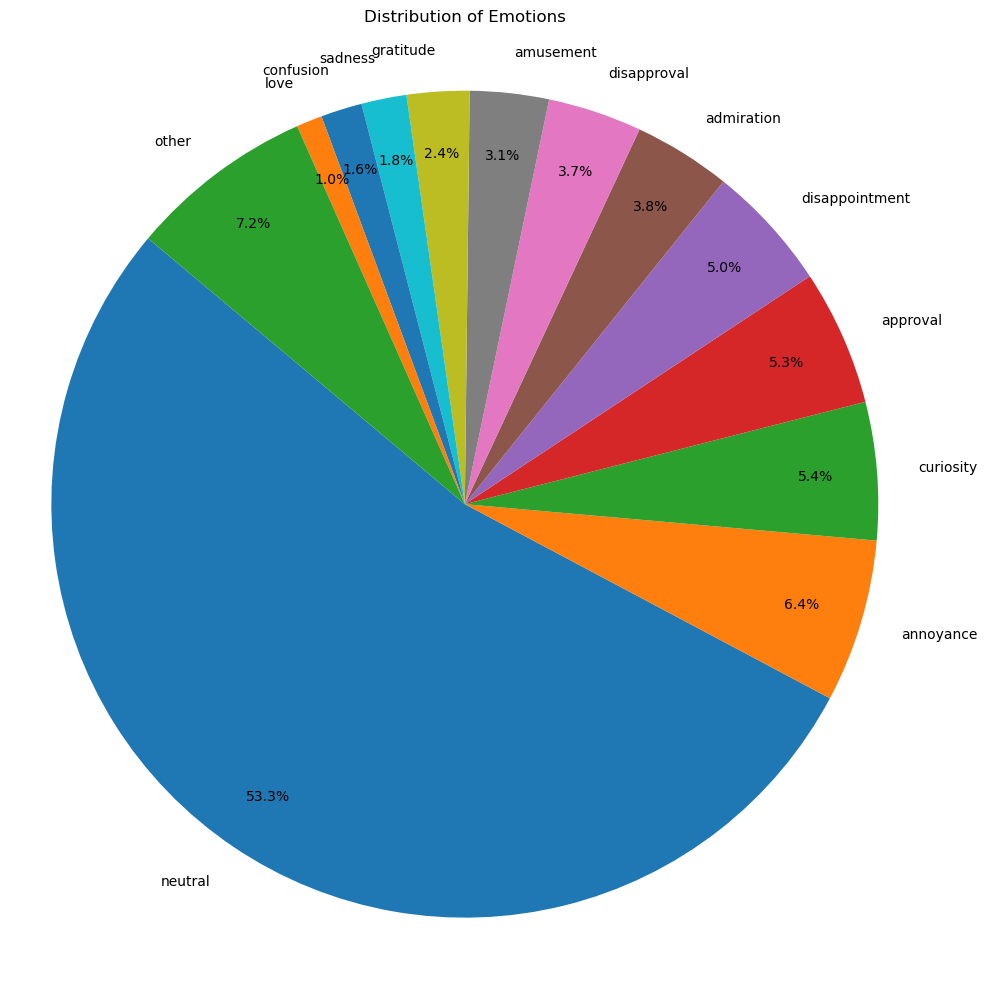

In [13]:
processor.outputGraphEmotionPieChart(comm2, 12)

Topic 1:
labor like good australia right greens live video say know population housing great work life government party better sydney labour
Topic 2:
house housing property prices money home tax people houses buy market land rent government investment pay years homes supply properties
Topic 3:
people immigration australia government housing country stop like australian crisis think going need problem way australians immigrants jack migration want


c:\Users\Morgan\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


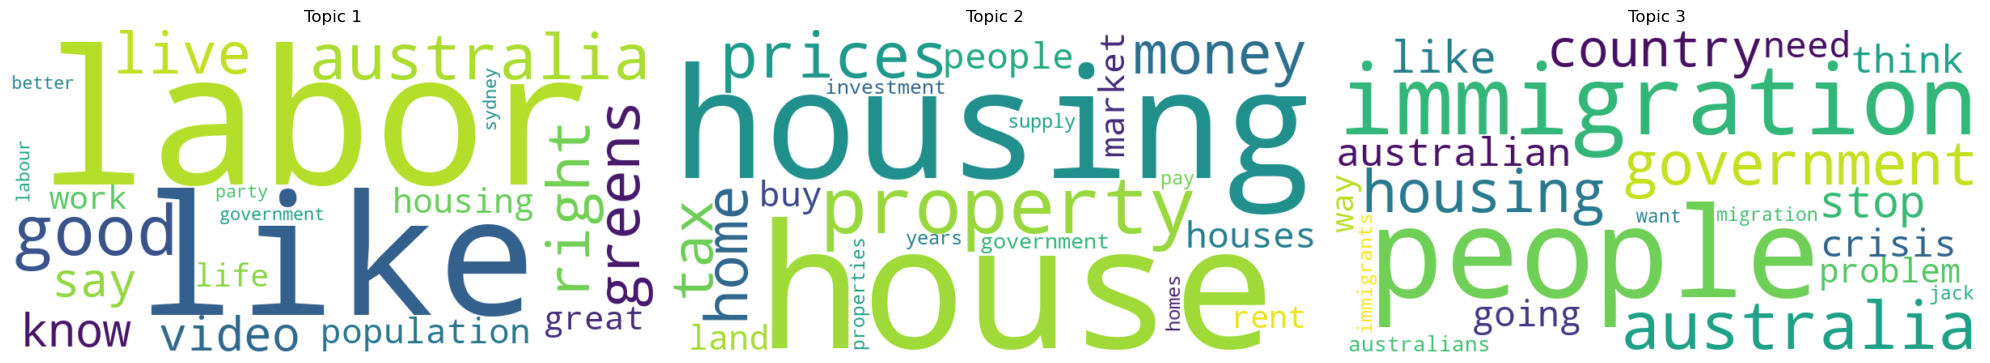

(LatentDirichletAllocation(learning_method='online', n_components=3),
 <Compressed Sparse Row sparse matrix of dtype 'int64'
 	with 218120 stored elements and shape (20085, 1500)>)

In [14]:
processor.getLDAModel(df, 3, 20, 1500)

Generates code and LDA visulisation html file